In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/ieee-fraud-detection/sample_submission.csv
/kaggle/input/competitions/ieee-fraud-detection/test_identity.csv
/kaggle/input/competitions/ieee-fraud-detection/train_identity.csv
/kaggle/input/competitions/ieee-fraud-detection/test_transaction.csv
/kaggle/input/competitions/ieee-fraud-detection/train_transaction.csv


In [2]:
!pip install dagshub mlflow xgboost -q
!pip install dagshub
!pip install mlflow
import xgboost as xgb
import mlflow
import mlflow.xgboost
import dagshub
import warnings
import json
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
warnings.filterwarnings('ignore')

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.metrics import roc_auc_score, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.feature_selection import SelectFromModel

dagshub.init(repo_owner='akave23', repo_name='IEEE-CIS-Fraud-Detection-ML2', mlflow=True)
mlflow.set_experiment('XGBoost_Training_v1')

print(f'XGBoost version : {xgb.__version__}')
print(f'MLflow URI      : {mlflow.get_tracking_uri()}')

ERROR: unknown command "instal" - maybe you meant "install"


Accessing as akave23

Initialized MLflow to track repo "akave23/IEEE-CIS-Fraud-Detection-ML2"

Repository akave23/IEEE-CIS-Fraud-Detection-ML2 initialized!

XGBoost version : 3.2.0
MLflow URI      : https://dagshub.com/akave23/IEEE-CIS-Fraud-Detection-ML2.mlflow


In [3]:
train = pd.read_csv('/kaggle/input/competitions/ieee-fraud-detection/train_transaction.csv').merge(
    pd.read_csv('/kaggle/input/competitions/ieee-fraud-detection/train_identity.csv'),
    on='TransactionID', how='left')

y = train['isFraud'].values
X = train.drop(['isFraud', 'TransactionID'], axis=1)

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f'X_train : {X_train.shape} | y_train : {y_train.shape} | fraud: {y_train.mean():.2%}')
print(f'X_valid : {X_valid.shape} | y_valid : {y_valid.shape} | fraud: {y_valid.mean():.2%}')


X_train : (472432, 432) | y_train : (472432,) | fraud: 3.50%
X_valid : (118108, 432) | y_valid : (118108,) | fraud: 3.50%


In [4]:
cat_cols  = X_train.select_dtypes(include='object').columns.tolist()
num_cols  = X_train.select_dtypes(include=np.number).columns.tolist()
print(f'Categorical cols: {len(cat_cols)} | Numeric cols: {len(num_cols)}')

Categorical cols: 31 | Numeric cols: 401


## **cleaning**

In [ ]:
from sklearn.impute import SimpleImputer

with mlflow.start_run(run_name='XGBoost_Cleaning'):

    X_tr  = X_train.reset_index(drop=True).copy()
    X_val = X_valid.reset_index(drop=True).copy()

   
    #  Remove high-NaN colს(> 90%)

    nan_pct       = X_tr.isnull().mean()
    high_nan_cols = nan_pct[nan_pct > 0.90].index.tolist()
    for df in [X_tr, X_val]:
        df.drop(columns=[c for c in high_nan_cols if c in df.columns], inplace=True)
    print(f'STEP 1 | High-NaN removed (>90%): {len(high_nan_cols)}')

    # add missing indicators
    missing_cols = [c for c in X_tr.columns if X_tr[c].isnull().any()]
    for col in missing_cols:
        flag        = col + '_was_nan'
        X_tr[flag]  = X_tr[col].isnull().astype(np.int8)
        X_val[flag] = X_val[col].isnull().astype(np.int8) if col in X_val.columns else 0
    print(f'STEP 2 | NaN indicators added: {len(missing_cols)}')


    cat_cols  = X_tr.select_dtypes(include='object').columns.tolist()
    high_card = [c for c in cat_cols if X_tr[c].nunique() > 10]
    low_card  = [c for c in cat_cols if X_tr[c].nunique() <= 10]
    cat_cardinalities = {c: int(X_tr[c].nunique()) for c in cat_cols}
    print(f'STEP 3 | Categorical cols: {len(cat_cols)}  (high-card: {len(high_card)}, low-card: {len(low_card)})')
    print(f'         High-card cols: {high_card}')
    print(f'         Low-card  cols: {low_card}')


    # Median imputation
 
    num_cols_only = X_tr.select_dtypes(include=np.number).columns.tolist()
    nan_counts_before = {col: int(X_tr[col].isnull().sum())
                         for col in missing_cols if col in X_tr.columns and col in num_cols_only}

    imputer_num  = SimpleImputer(strategy='median')
    X_tr[num_cols_only]  = imputer_num.fit_transform(X_tr[num_cols_only])
    X_val[num_cols_only] = imputer_num.transform(X_val[num_cols_only])
    print(f'STEP 4 | Numeric median imputation done. NaN in numeric cols: {X_tr[num_cols_only].isnull().sum().sum()}')


    #    Outlier capping 
    skip_cap   = [c for c in num_cols_only if c.endswith('_was_nan') or c == 'TransactionDT']
    cap_cols   = [c for c in num_cols_only if c not in skip_cap]
    cap_bounds = {}
    capped_info = {}
    for col in cap_cols:
        lo, hi = X_tr[col].quantile(0.01), X_tr[col].quantile(0.99)
        n = int(((X_tr[col] < lo) | (X_tr[col] > hi)).sum())
        if n > 0:
            cap_bounds[col]  = (lo, hi)
            capped_info[col] = round(n / len(X_tr) * 100, 2)
            for df in [X_tr, X_val]:
                df[col] = df[col].clip(lo, hi)
    print(f'STEP 5 | Outlier capping applied to {len(capped_info)} columns')


    #   High-correlation filter 
  
    num_for_corr = X_tr.select_dtypes(include=np.number).columns
    corr_matrix  = X_tr[num_for_corr].corr().abs()
    upper        = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    high_corr    = [c for c in upper.columns if any(upper[c] > 0.95)]
    for df in [X_tr, X_val]:
        df.drop(columns=[c for c in high_corr if c in df.columns], inplace=True)
    print(f'STEP 6 | High-corr removed (>0.95): {len(high_corr)}')


    # Low-variance removal
 
    num_for_var  = X_tr.select_dtypes(include=np.number).columns
    low_var_cols = X_tr[num_for_var].var()[X_tr[num_for_var].var() < 0.01].index.tolist()
    for df in [X_tr, X_val]:
        df.drop(columns=[c for c in low_var_cols if c in df.columns], inplace=True)
    print(f'STEP 7 | Low-variance removed: {len(low_var_cols)}')

    assert X_tr.shape[0]  == len(y_train)
    assert X_val.shape[0] == len(y_valid)

    print(f'\nCleaning done — X_tr: {X_tr.shape} | X_val: {X_val.shape}')
    print(f'Object cols still present: {X_tr.select_dtypes("object").shape[1]}  ← will be encoded in FE')

    mlflow.log_param('imputation',     'median_numeric')
    mlflow.log_param('outlier_cap',    '1pct-99pct')
    mlflow.log_param('corr_threshold', 0.95)
    mlflow.log_metric('removed_high_nan',     len(high_nan_cols))
    mlflow.log_metric('added_nan_indicators', len(missing_cols))
    mlflow.log_metric('removed_high_corr',    len(high_corr))
    mlflow.log_metric('removed_low_var',      len(low_var_cols))
    mlflow.log_metric('cat_cols_pending_enc', len(cat_cols))

STEP 1 | High-NaN removed (>90%): 12
STEP 2 | NaN indicators added: 402
STEP 3 | Categorical cols: 29  (high-card: 6, low-card: 23)
         High-card cols: ['P_emaildomain', 'R_emaildomain', 'id_30', 'id_31', 'id_33', 'DeviceInfo']
         Low-card  cols: ['ProductCD', 'card4', 'card6', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'id_12', 'id_15', 'id_16', 'id_28', 'id_29', 'id_34', 'id_35', 'id_36', 'id_37', 'id_38', 'DeviceType']
STEP 4 | Numeric median imputation done. NaN in numeric cols: 0
STEP 5 | Outlier capping applied to 390 columns
STEP 6 | High-corr removed (>0.95): 456
STEP 7 | Low-variance removed: 55

Cleaning done — X_tr: (472432, 311) | X_val: (118108, 311)
Object cols still present: 29  ← will be encoded in FE
🏃 View run XGBoost_Cleaning at: https://dagshub.com/akave23/IEEE-CIS-Fraud-Detection-ML2.mlflow/#/experiments/2/runs/377ce297bbcd43dba59f1c21f9f2a0aa
🧪 View experiment at: https://dagshub.com/akave23/IEEE-CIS-Fraud-Detection-ML2.mlflow/#/experiments/2

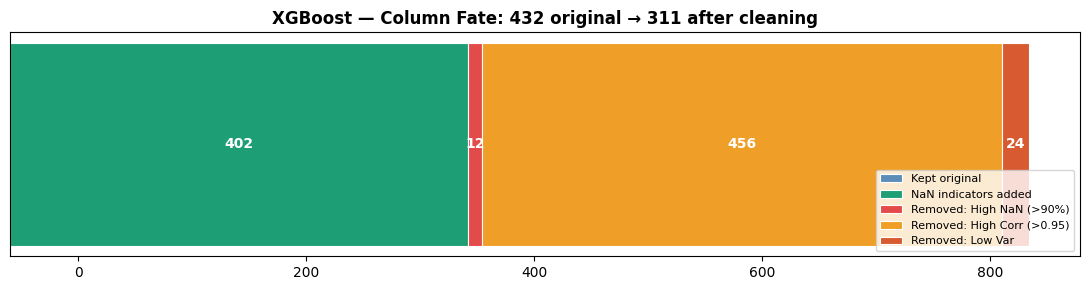

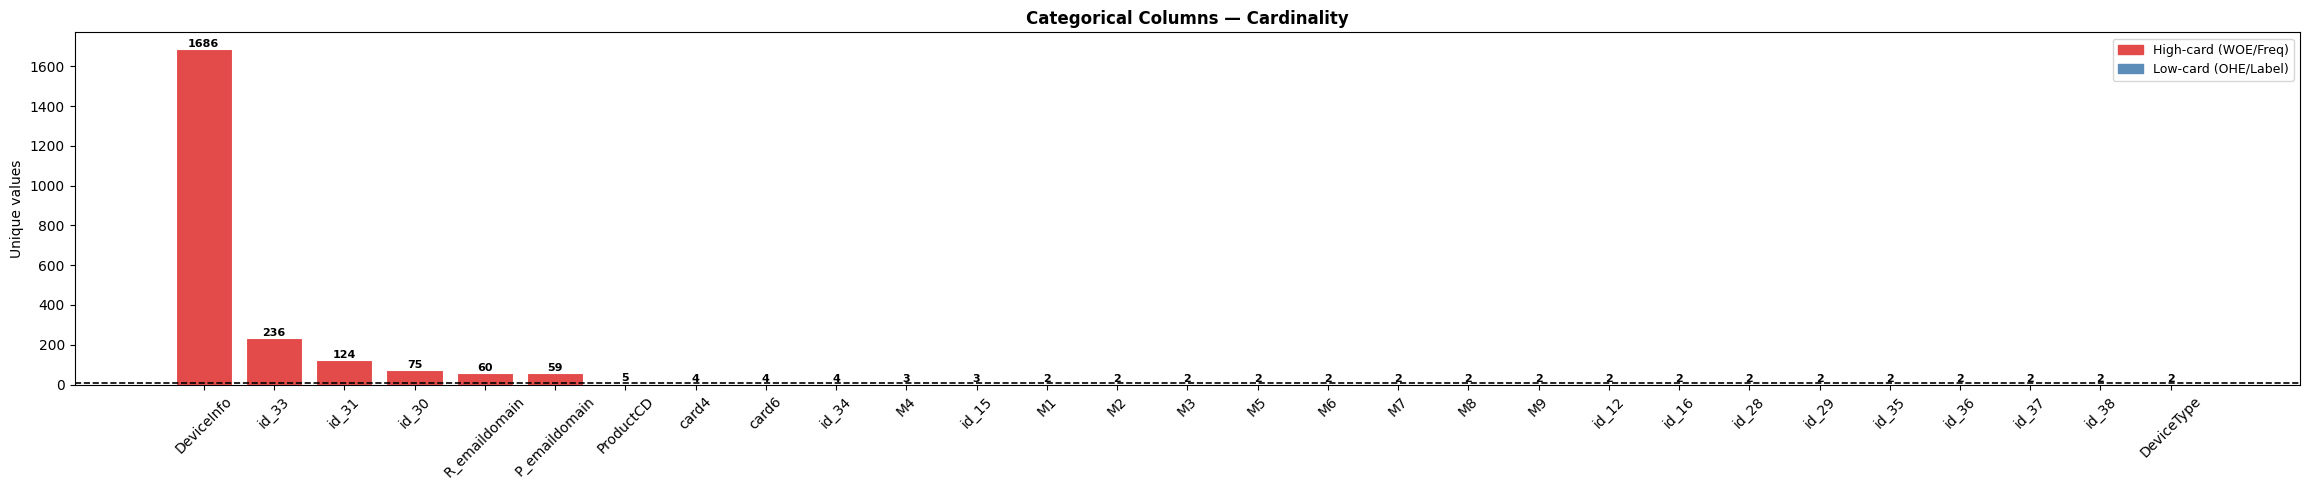

Cleaning charts saved.


In [ ]:
n_orig       = X_train.shape[1]
n_kept       = n_orig - len(high_nan_cols) - len(high_corr) - len(low_var_cols)
n_indicators = len(missing_cols)
n_after_clean = X_tr.shape[1]


fig, ax = plt.subplots(figsize=(11, 3))
segments = [
    ('Kept original',              n_kept,             '#5B8DB8'),
    ('NaN indicators added',       n_indicators,       '#1D9E75'),
    ('Removed: High NaN (>90%)',   len(high_nan_cols), '#E24B4A'),
    ('Removed: High Corr (>0.95)', len(high_corr),     '#EF9F27'),
    ('Removed: Low Var',           len(low_var_cols),  '#D85A30'),
]
left = 0
for lbl, val, col in segments:
    ax.barh(['columns'], [val], left=left, color=col, edgecolor='white', linewidth=0.8, label=lbl)
    if val > 6:
        ax.text(left + val/2, 0, str(val), ha='center', va='center',
                fontsize=10, fontweight='bold', color='white')
    left += val
ax.set_title(f'XGBoost — Column Fate: {n_orig} original → {n_after_clean} after cleaning', fontsize=12, fontweight='bold')
ax.legend(loc='lower right', fontsize=8)
ax.set_yticks([])
plt.tight_layout()
plt.savefig('xgb_chart1_column_fate.png', dpi=130, bbox_inches='tight')
plt.show()


if cat_cardinalities:
    sc = dict(sorted(cat_cardinalities.items(), key=lambda x: x[1], reverse=True))
    cc = ['#E24B4A' if v > 10 else '#5B8DB8' for v in sc.values()]
    fig, ax = plt.subplots(figsize=(max(8, len(sc)*0.8), 5))
    bars = ax.bar(sc.keys(), sc.values(), color=cc, edgecolor='white', linewidth=0.8)
    for bar, v in zip(bars, sc.values()):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                str(v), ha='center', va='bottom', fontsize=8, fontweight='bold')
    ax.axhline(10, color='black', linestyle='--', linewidth=1.2, label='High-card threshold=10')
    ax.set_title('Categorical Columns — Cardinality', fontsize=12, fontweight='bold')
    ax.set_ylabel('Unique values')
    ax.tick_params(axis='x', rotation=45)
    ax.legend(handles=[mpatches.Patch(color='#E24B4A', label='High-card (WOE/Freq)'),
                       mpatches.Patch(color='#5B8DB8', label='Low-card (OHE/Label)')], fontsize=9)
    plt.tight_layout()
    plt.savefig('xgb_chart2_cardinality.png', dpi=130, bbox_inches='tight')
    plt.show()

print('Cleaning charts saved.')

In [ ]:
#  WOE / IV helpers

def compute_woe_iv(df_col, y, col_name, min_samples=50):
    df_tmp = pd.DataFrame({'cat': df_col.astype(str), 'target': y})

    total_events     = max(df_tmp['target'].sum(), 1)
    total_non_events = max((1 - df_tmp['target']).sum(), 1)

    stats = df_tmp.groupby('cat')['target'].agg(['sum', 'count']).reset_index()
    stats.columns = ['cat', 'events', 'total']
    stats['non_events'] = stats['total'] - stats['events']


    stats['events_pct']     = stats['events']     / total_events
    stats['non_events_pct'] = stats['non_events'] / total_non_events


    eps = 1e-6
    stats['woe'] = np.where(
        stats['total'] < min_samples,
        0.0,
        np.log((stats['events_pct'] + eps) / (stats['non_events_pct'] + eps))
    )
    stats['iv_contrib'] = (stats['events_pct'] - stats['non_events_pct']) * stats['woe']
    stats['iv_contrib'] = stats['iv_contrib'].where(stats['total'] >= min_samples, 0.0)

    iv      = stats['iv_contrib'].sum()
    woe_map = dict(zip(stats['cat'], stats['woe']))

    stats['column'] = col_name
    return woe_map, iv, stats


def iv_strength(iv):
    """Standard IV interpretation."""
    if iv < 0.02:  return 'Useless'
    if iv < 0.10:  return 'Weak'
    if iv < 0.30:  return 'Medium'
    if iv < 0.50:  return 'Strong'
    return 'Very Strong'



In [ ]:
with mlflow.start_run(run_name='XGBoost_Feature_Engineering'):

    n_before = X_tr.shape[1]
    woe_maps     = {}   
    iv_scores    = {}   
    woe_details  = []  
    ohe_cols_used = []
    freq_cols_used = []

    cat_cols_cur  = X_tr.select_dtypes(include='object').columns.tolist()

    print('=== Computing WOE + IV for all categorical columns ===')
    for col in cat_cols_cur:
        woe_map, iv, details = compute_woe_iv(X_tr[col], y_train, col)
        woe_maps[col]  = woe_map
        iv_scores[col] = iv
        woe_details.append(details)
        print(f'  {col:30s}  IV={iv:.4f}  [{iv_strength(iv)}]')

    iv_df = pd.DataFrame.from_dict(
        {'column': list(iv_scores.keys()), 'iv': list(iv_scores.values())}
    ).sort_values('iv', ascending=False)
    iv_df['strength'] = iv_df['iv'].apply(iv_strength)

    print(f'\nIV Summary:')
    print(iv_df.to_string(index=False))


    useless_cats = iv_df[iv_df['iv'] < 0.02]['column'].tolist()
    woe_encode   = [c for c in cat_cols_cur
                    if c not in useless_cats
                    and X_tr[c].nunique() > 6
                    and X_tr[c].nunique() <= 100]
    ohe_encode   = [c for c in cat_cols_cur
                    if c not in useless_cats
                    and X_tr[c].nunique() <= 6]
    freq_encode  = [c for c in cat_cols_cur
                    if c not in useless_cats
                    and X_tr[c].nunique() > 100]

    print(f'\nEncoding decisions:')
    print(f'  Dropped (IV<0.02)     : {useless_cats}')
    print(f'  WOE encoded           : {woe_encode}')
    print(f'  OHE encoded (card≤6)  : {ohe_encode}')
    print(f'  Freq encoded (card>100): {freq_encode}')


    for df in [X_tr, X_val]:
        df.drop(columns=[c for c in useless_cats if c in df.columns], inplace=True)

    # WOE Encoding 
    for col in woe_encode:
        woe_col = col + '_woe'
        X_tr[woe_col]  = X_tr[col].astype(str).map(woe_maps[col]).fillna(0.0)
        X_val[woe_col] = X_val[col].astype(str).map(woe_maps[col]).fillna(0.0)
        # drop original after WOE
        for df in [X_tr, X_val]:
            df.drop(columns=[col], inplace=True, errors='ignore')

    ohe_fitted_cols = {}  
    freq_maps_enc   = {}  

    for col in ohe_encode:
        X_tr[col]  = X_tr[col].fillna('missing').astype(str)
        X_val[col] = X_val[col].fillna('missing').astype(str)

        ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore', dtype=np.int8)
        ohe.fit(X_tr[[col]])                            

        new_cols = [f'{col}_ohe_{c}' for c in ohe.categories_[0]]
        ohe_fitted_cols[col] = {'encoder': ohe, 'new_cols': new_cols}
        ohe_cols_used.append(col)

        for df in [X_tr, X_val]:
            encoded = pd.DataFrame(
                ohe.transform(df[[col]]),
                columns=new_cols,
                index=df.index
            )
            df.drop(columns=[col], inplace=True)
            df[new_cols] = encoded

    # Frequency Encoding 
    for col in freq_encode:
        fm = X_tr[col].value_counts(normalize=True).to_dict()  
        freq_maps_enc[col] = fm
        freq_cols_used.append(col)
        for df in [X_tr, X_val]:
            df[col + '_freq'] = df[col].map(fm).fillna(0.0)
            df.drop(columns=[col], inplace=True)

    #  Label Encoding
    remaining_obj = X_tr.select_dtypes(include='object').columns.tolist()
    label_encoders = {}
    for col in remaining_obj:
        le = LabelEncoder()
        vocab = pd.concat([X_tr[col], X_val[col]], axis=0).astype(str)
        le.fit(vocab)
        label_encoders[col] = le
        for df in [X_tr, X_val]:
            df[col] = le.transform(df[col].astype(str))
    if remaining_obj:
        print(f'  Remaining obj cols label-encoded: {remaining_obj}')


    assert len(X_tr.select_dtypes(include='object').columns) == 0, 'Object cols still present!'

 #adding features
    if 'TransactionDT' in X_tr.columns:
        for df in [X_tr, X_val]:
            df['hour_of_day']  = (df['TransactionDT'] // 3600) % 24
            df['day_of_week']  = (df['TransactionDT'] // 86400) % 7
            df['day_of_month'] = (df['TransactionDT'] // 86400) % 30
            df['is_weekend']   = (df['day_of_week'] >= 5).astype(int)
            df['is_night']     = ((df['hour_of_day'] >= 22) | (df['hour_of_day'] <= 5)).astype(int)


    if 'TransactionAmt' in X_tr.columns:
        for df in [X_tr, X_val]:
            df['amt_log']      = np.log1p(df['TransactionAmt'])
            df['amt_decimal']  = df['TransactionAmt'] % 1
            df['amt_is_round'] = (df['TransactionAmt'] % 1 < 0.01).astype(int)
            df['amt_cents']    = (df['TransactionAmt'] * 100).astype(int) % 100


    if 'card1' in X_tr.columns and 'TransactionAmt' in X_tr.columns:
        c1_stats = X_tr.groupby('card1')['TransactionAmt'].agg(
            card1_mean='mean', card1_std='std', card1_count='count').reset_index()
        for df in [X_tr, X_val]:
            df  = df.merge(c1_stats, on='card1', how='left')
        for col in ['card1_mean', 'card1_std', 'card1_count']:
            med = X_tr[col].median() if col in X_tr.columns else 0
            for df in [X_tr, X_val]:
                if col in df.columns:
                    df[col].fillna(med, inplace=True)

    n_after = X_tr.shape[1]
    assert X_tr.shape[0]  == len(y_train)
    assert X_val.shape[0] == len(y_valid)

    print(f'\nFeature Engineering done: {n_before} -> {n_after} features')

  
    imputer_final = SimpleImputer(strategy='median')
    col_names     = X_tr.columns.tolist()
    X_tr  = pd.DataFrame(imputer_final.fit_transform(X_tr),  columns=col_names)
    X_val = pd.DataFrame(imputer_final.transform(X_val),      columns=col_names)
    print(f'Final imputation — NaN in X_tr: {X_tr.isnull().sum().sum()}')

    mlflow.log_metric('features_before_fe',   n_before)
    mlflow.log_metric('features_after_fe',    n_after)
    mlflow.log_metric('woe_encoded_cols',     len(woe_encode))
    mlflow.log_metric('ohe_encoded_cols',     len(ohe_encode))
    mlflow.log_metric('freq_encoded_cols',    len(freq_encode))
    mlflow.log_metric('dropped_useless_cats', len(useless_cats))
    for col, iv in iv_scores.items():
        mlflow.log_metric(f'iv_{col}', round(iv, 4))

=== Computing WOE + IV for all categorical columns ===
  ProductCD                       IV=0.5541  [Very Strong]
  card4                           IV=0.0127  [Useless]
  card6                           IV=0.2538  [Medium]
  P_emaildomain                   IV=0.1820  [Medium]
  R_emaildomain                   IV=0.6275  [Very Strong]
  M1                              IV=0.2363  [Medium]
  M2                              IV=0.2604  [Medium]
  M3                              IV=0.2647  [Medium]
  M4                              IV=0.4533  [Strong]
  M5                              IV=0.0197  [Useless]
  M6                              IV=0.4037  [Strong]
  M7                              IV=0.1576  [Medium]
  M8                              IV=0.1646  [Medium]
  M9                              IV=0.1710  [Medium]
  id_12                           IV=0.4341  [Strong]
  id_15                           IV=0.4862  [Strong]
  id_16                           IV=0.4210  [Strong]
  id_28        

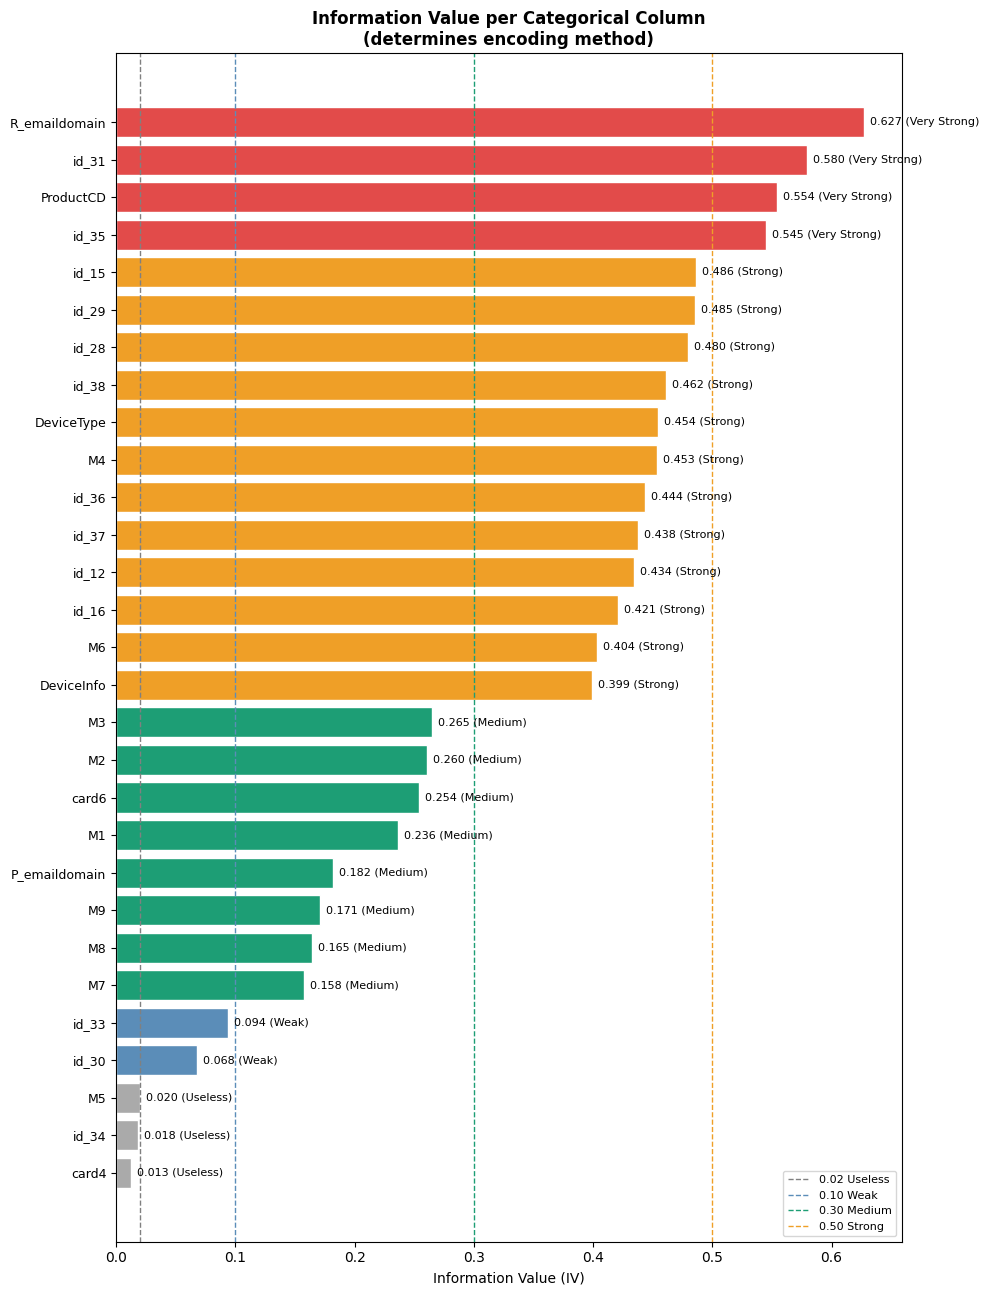

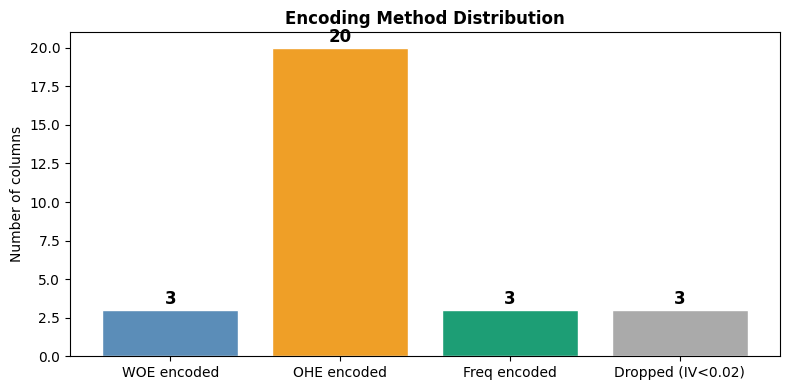

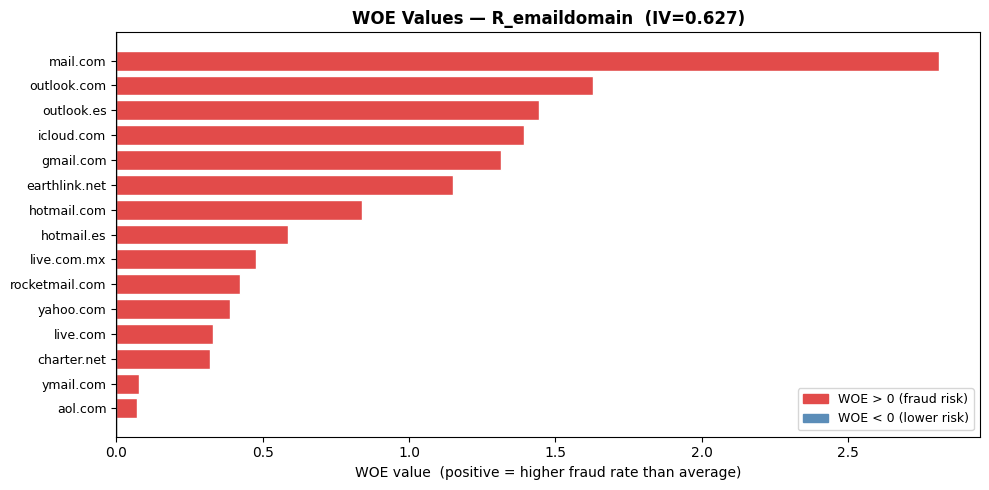

FE charts saved.


In [ ]:
fig, ax = plt.subplots(figsize=(10, max(4, len(iv_df)*0.45)))
iv_colors = [
    '#E24B4A' if s == 'Very Strong' else
    '#EF9F27' if s == 'Strong' else
    '#1D9E75' if s == 'Medium' else
    '#5B8DB8' if s == 'Weak' else
    '#aaaaaa'
    for s in iv_df['strength']
]
bars = ax.barh(range(len(iv_df)), iv_df['iv'].values, color=iv_colors, edgecolor='white')
ax.set_yticks(range(len(iv_df)))
ax.set_yticklabels(iv_df['column'].values, fontsize=9)
ax.invert_yaxis()
ax.axvline(0.02, color='gray',    linestyle='--', linewidth=1, label='0.02 Useless')
ax.axvline(0.10, color='#5B8DB8', linestyle='--', linewidth=1, label='0.10 Weak')
ax.axvline(0.30, color='#1D9E75', linestyle='--', linewidth=1, label='0.30 Medium')
ax.axvline(0.50, color='#EF9F27', linestyle='--', linewidth=1, label='0.50 Strong')
for i, (v, s) in enumerate(zip(iv_df['iv'].values, iv_df['strength'].values)):
    ax.text(v + 0.005, i, f'{v:.3f} ({s})', va='center', fontsize=8)
ax.set_xlabel('Information Value (IV)')
ax.set_title('Information Value per Categorical Column\n(determines encoding method)', fontsize=12, fontweight='bold')
ax.legend(fontsize=8, loc='lower right')
plt.tight_layout()
plt.savefig('xgb_chart3_iv_scores.png', dpi=130, bbox_inches='tight')
plt.show()

enc_summary = {
    'WOE encoded':    len(woe_encode),
    'OHE encoded':    len(ohe_encode),
    'Freq encoded':   len(freq_encode),
    'Dropped (IV<0.02)': len(useless_cats),
}
fig, ax = plt.subplots(figsize=(8, 4))
ec = ['#5B8DB8','#EF9F27','#1D9E75','#aaaaaa']
bars = ax.bar(enc_summary.keys(), enc_summary.values(), color=ec, edgecolor='white')
for bar, v in zip(bars, enc_summary.values()):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
            str(v), ha='center', va='bottom', fontsize=12, fontweight='bold')
ax.set_title('Encoding Method Distribution', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of columns')
plt.tight_layout()
plt.savefig('xgb_chart4_encoding_dist.png', dpi=130, bbox_inches='tight')
plt.show()


if woe_encode and woe_details:
    best_woe_col = iv_df[iv_df['column'].isin(woe_encode)].iloc[0]['column'] if len(iv_df[iv_df['column'].isin(woe_encode)]) > 0 else None
    if best_woe_col:
        best_details = pd.concat(woe_details)
        best_details = best_details[best_details['column'] == best_woe_col].sort_values('woe', ascending=False).head(15)
        fig, ax = plt.subplots(figsize=(10, 5))
        woe_colors = ['#E24B4A' if w > 0 else '#5B8DB8' for w in best_details['woe']]
        ax.barh(range(len(best_details)), best_details['woe'].values, color=woe_colors, edgecolor='white')
        ax.set_yticks(range(len(best_details)))
        ax.set_yticklabels(best_details['cat'].values, fontsize=9)
        ax.invert_yaxis()
        ax.axvline(0, color='black', linewidth=1)
        ax.set_xlabel('WOE value  (positive = higher fraud rate than average)')
        ax.set_title(f'WOE Values — {best_woe_col}  (IV={iv_scores[best_woe_col]:.3f})',
                     fontsize=12, fontweight='bold')
        ax.legend(handles=[mpatches.Patch(color='#E24B4A', label='WOE > 0 (fraud risk)'),
                            mpatches.Patch(color='#5B8DB8', label='WOE < 0 (lower risk)')], fontsize=9)
        plt.tight_layout()
        plt.savefig('xgb_chart5_woe_values.png', dpi=130, bbox_inches='tight')
        plt.show()

print('FE charts saved.')

In [ ]:
def compute_iv_numeric(series, y, n_bins=10):
    """
    IV for a numeric feature using quantile binning.
    """
    try:
        binned = pd.qcut(series, q=n_bins, duplicates='drop').astype(str)
        woe_map, iv, _ = compute_woe_iv(binned, y, series.name)
        return iv
    except Exception:
        return 0.0


print('Computing IV for all features (numeric + encoded)...')
all_iv = {}
for col in X_tr.columns:
    if X_tr[col].dtype == object:
        _, iv, _ = compute_woe_iv(X_tr[col], y_train, col)
    else:
        iv = compute_iv_numeric(X_tr[col], y_train)
    all_iv[col] = iv

all_iv_df = pd.DataFrame.from_dict(
    {'feature': list(all_iv.keys()), 'iv': list(all_iv.values())}
).sort_values('iv', ascending=False)
all_iv_df['strength'] = all_iv_df['iv'].apply(iv_strength)

print(f'Total features: {len(all_iv_df)}')
print(f'IV >= 0.02: {(all_iv_df["iv"] >= 0.02).sum()}')
print(f'IV <  0.02: {(all_iv_df["iv"] <  0.02).sum()}')

Computing IV for all features (numeric + encoded)...
Total features: 363
IV >= 0.02: 84
IV <  0.02: 279


=== Method A: IV-based (drop IV < 0.02) ===
  Selected: 84 / 363 | Val AUC = 0.9156

=== Method B: XGBoost Gain Importance (drop bottom 10%) ===
  Selected: 325 / 363 | Val AUC = 0.9192

=== Method C: SelectFromModel (mean threshold) ===
  Selected: 64 / 363 | Val AUC = 0.8824

=== Feature Selection Comparison ===
                   method  n_features  val_auc
 B: XGB Gain (bottom 10%)         325 0.919213
       A: IV (drop <0.02)          84 0.915574
C: SelectFromModel (mean)          64 0.882393


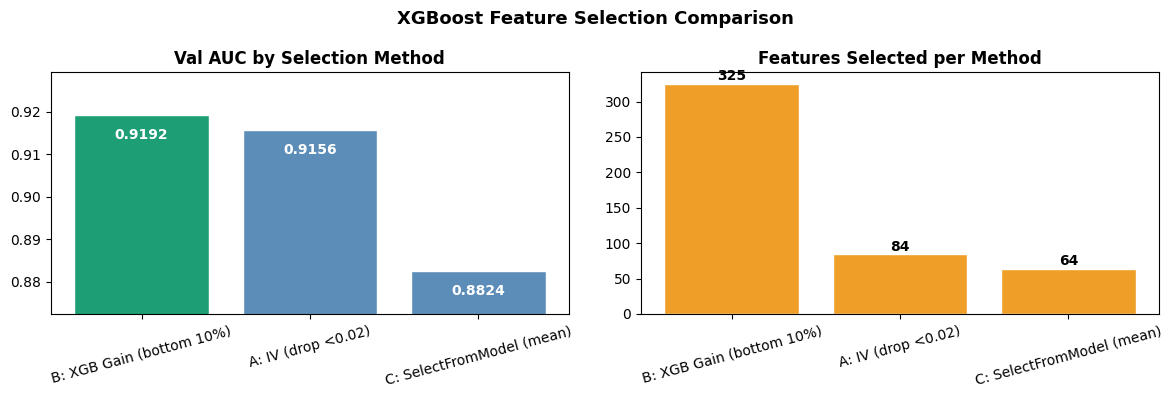

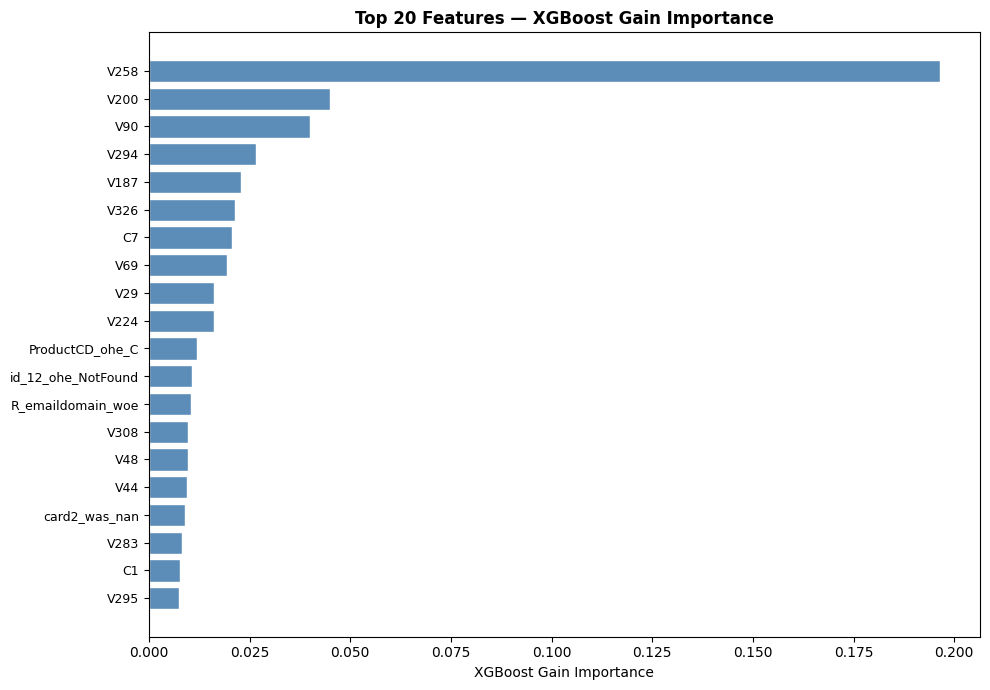


Final features: 325 (best method: B: XGB Gain (bottom 10%))
X_tr_sel: (472432, 325) | X_val_sel: (118108, 325)
🏃 View run XGBoost_Feature_Selection at: https://dagshub.com/akave23/IEEE-CIS-Fraud-Detection-ML2.mlflow/#/experiments/2/runs/9ea3926a5c374c28bfcbdf70a910fa03
🧪 View experiment at: https://dagshub.com/akave23/IEEE-CIS-Fraud-Detection-ML2.mlflow/#/experiments/2


In [ ]:
with mlflow.start_run(run_name='XGBoost_Feature_Selection'):

    feature_names = X_tr.columns.tolist()
    n_total       = len(feature_names)

    # Method A:
    print('=== Method A: IV-based (drop IV < 0.02) ===')
    by_iv  = all_iv_df[all_iv_df['iv'] >= 0.02]['feature'].tolist()
    by_iv  = [f for f in by_iv if f in X_tr.columns]

    xgb_tmp = xgb.XGBClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.05,
        use_label_encoder=False, eval_metric='auc',
        tree_method='hist', device='cuda', random_state=42)
    xgb_tmp.fit(
        X_tr[by_iv].values, y_train,
        eval_set=[(X_val[by_iv].values, y_valid)],
        verbose=False)
    auc_iv = roc_auc_score(y_valid, xgb_tmp.predict_proba(X_val[by_iv].values)[:, 1])
    print(f'  Selected: {len(by_iv)} / {n_total} | Val AUC = {auc_iv:.4f}')

    # Method B: XGBoost Gain Importance
    print('\n=== Method B: XGBoost Gain Importance (drop bottom 10%) ===')
    xgb_fs = xgb.XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        use_label_encoder=False, eval_metric='auc',
        tree_method='hist', device='cuda', random_state=42)
    xgb_fs.fit(
        X_tr.values, y_train,
        eval_set=[(X_val.values, y_valid)],
        verbose=False)

    gain_importances = pd.Series(xgb_fs.feature_importances_, index=feature_names).sort_values(ascending=False)
    thr_b   = gain_importances.quantile(0.10)
    by_gain = gain_importances[gain_importances > thr_b].index.tolist()

    xgb_tmp.fit(
        X_tr[by_gain].values, y_train,
        eval_set=[(X_val[by_gain].values, y_valid)],
        verbose=False)
    auc_gain = roc_auc_score(y_valid, xgb_tmp.predict_proba(X_val[by_gain].values)[:, 1])
    print(f'  Selected: {len(by_gain)} / {n_total} | Val AUC = {auc_gain:.4f}')

    # Method C: SelectFromModel (mean threshold) 
    print('\n=== Method C: SelectFromModel (mean threshold) ===')
    sfm     = SelectFromModel(xgb_fs, threshold='mean', prefit=True)
    by_sfm  = [f for f, s in zip(feature_names, sfm.get_support()) if s]

    xgb_tmp.fit(
        X_tr[by_sfm].values, y_train,
        eval_set=[(X_val[by_sfm].values, y_valid)],
        verbose=False)
    auc_sfm = roc_auc_score(y_valid, xgb_tmp.predict_proba(X_val[by_sfm].values)[:, 1])
    print(f'  Selected: {len(by_sfm)} / {n_total} | Val AUC = {auc_sfm:.4f}')

  
    sel_results = [
        {'method': 'A: IV (drop <0.02)',       'n_features': len(by_iv),   'val_auc': auc_iv},
        {'method': 'B: XGB Gain (bottom 10%)', 'n_features': len(by_gain), 'val_auc': auc_gain},
        {'method': 'C: SelectFromModel (mean)','n_features': len(by_sfm),  'val_auc': auc_sfm},
    ]
    sel_df = pd.DataFrame(sel_results).sort_values('val_auc', ascending=False)
    print('\n=== Feature Selection Comparison ===')
    print(sel_df.to_string(index=False))

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    cs = ['#1D9E75' if i == 0 else '#5B8DB8' for i in range(len(sel_df))]
    axes[0].bar(sel_df['method'], sel_df['val_auc'], color=cs, edgecolor='white')
    for i, (_, row) in enumerate(sel_df.iterrows()):
        axes[0].text(i, row['val_auc']-0.003, f"{row['val_auc']:.4f}",
                     ha='center', va='top', fontsize=10, fontweight='bold', color='white')
    axes[0].set_ylim(min(sel_df['val_auc'])-0.01, max(sel_df['val_auc'])+0.01)
    axes[0].set_title('Val AUC by Selection Method', fontweight='bold')
    axes[0].tick_params(axis='x', rotation=15)

    axes[1].bar(sel_df['method'], sel_df['n_features'], color='#EF9F27', edgecolor='white')
    for i, (_, row) in enumerate(sel_df.iterrows()):
        axes[1].text(i, row['n_features']+1, str(row['n_features']),
                     ha='center', va='bottom', fontsize=10, fontweight='bold')
    axes[1].set_title('Features Selected per Method', fontweight='bold')
    axes[1].tick_params(axis='x', rotation=15)
    plt.suptitle('XGBoost Feature Selection Comparison', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('xgb_chart6_feature_selection.png', dpi=130, bbox_inches='tight')
    plt.show()

# Top 20 feature importance chart
    fig, ax = plt.subplots(figsize=(10, 7))
    top20 = gain_importances.head(20)
    ax.barh(range(len(top20)), top20.values, color='#5B8DB8', edgecolor='white')
    ax.set_yticks(range(len(top20)))
    ax.set_yticklabels(top20.index, fontsize=9)
    ax.invert_yaxis()
    ax.set_xlabel('XGBoost Gain Importance')
    ax.set_title('Top 20 Features — XGBoost Gain Importance', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig('xgb_feature_importance.png', dpi=130, bbox_inches='tight')
    plt.show()


    best_sel = sel_df.iloc[0]['method']
    if 'IV' in best_sel:
        FINAL_FEATURES = by_iv
    elif 'Gain' in best_sel:
        FINAL_FEATURES = by_gain
    else:
        FINAL_FEATURES = by_sfm

    X_tr_sel  = X_tr[FINAL_FEATURES].copy()
    X_val_sel = X_val[FINAL_FEATURES].copy()

    with open('xgb_selected_features.json', 'w') as f:
        json.dump(FINAL_FEATURES, f)

    mlflow.log_param('best_method',        best_sel)
    mlflow.log_metric('features_total',    n_total)
    mlflow.log_metric('features_iv',       len(by_iv))
    mlflow.log_metric('features_gain',     len(by_gain))
    mlflow.log_metric('features_sfm',      len(by_sfm))
    mlflow.log_metric('features_final',    len(FINAL_FEATURES))
    mlflow.log_metric('val_auc_iv',        auc_iv)
    mlflow.log_metric('val_auc_gain',      auc_gain)
    mlflow.log_metric('val_auc_sfm',       auc_sfm)
    mlflow.log_artifact('xgb_chart6_feature_selection.png')
    mlflow.log_artifact('xgb_feature_importance.png')
    mlflow.log_artifact('xgb_chart3_iv_scores.png')
    mlflow.log_artifact('xgb_selected_features.json')

    print(f'\nFinal features: {len(FINAL_FEATURES)} (best method: {best_sel})')
    print(f'X_tr_sel: {X_tr_sel.shape} | X_val_sel: {X_val_sel.shape}')

In [14]:
def run_cv_xgb(X_features, y_target, model_params, n_splits=5):
    X_arr = X_features.values if hasattr(X_features, 'values') else X_features
    skf   = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    oof   = np.zeros(len(y_target))
    cv_aucs, tr_aucs = [], []

    for fold, (tr_idx, val_idx) in enumerate(skf.split(X_arr, y_target)):
        X_tr_f,  X_v_f  = X_arr[tr_idx], X_arr[val_idx]
        y_tr_f,  y_v_f  = y_target[tr_idx], y_target[val_idx]

        model = xgb.XGBClassifier(**model_params)
        model.fit(
            X_tr_f, y_tr_f,
            eval_set=[(X_v_f, y_v_f)],
            verbose=False)

        oof[val_idx] = model.predict_proba(X_v_f)[:, 1]
        cv_aucs.append(roc_auc_score(y_v_f,  oof[val_idx]))
        tr_aucs.append(roc_auc_score(y_tr_f, model.predict_proba(X_tr_f)[:, 1]))
        print(f'  Fold {fold+1}: Val={cv_aucs[-1]:.4f} | Train={tr_aucs[-1]:.4f} | Gap={tr_aucs[-1]-cv_aucs[-1]:.4f}')

    return cv_aucs, tr_aucs, oof

print(f'CV helper ready.')
print(f'Training: X_tr_sel={X_tr_sel.shape} | y_train={y_train.shape}')

CV helper ready.
Training: X_tr_sel=(472432, 325) | y_train=(472432,)


In [ ]:
from sklearn.metrics import average_precision_score, roc_auc_score

configs = [
    ('XGB_depth4_lr01',  4, 0.1, 50,   0.8, 0.8, 0.1, 1.0, 100),
    ('XGB_depth6_lr05',  6, 0.05, 1500, 0.8, 0.7, 0.1, 1.0, 50),
    ('XGB_depth6_lr01',  6, 0.01, 3000, 0.8, 0.7, 0.1, 1.0, 20),
    ('XGB_depth8_lr05',  8, 0.05, 1500, 0.8, 0.7, 0.1, 1.0, 10),
    ('XGB_depth6_reg',   6, 0.05, 1500, 0.7, 0.7, 1.0, 5.0, 10),
    ('XGB_depth6_col5',  6, 0.05, 1500, 0.8, 0.5, 0.1, 1.0, 5),
    ('XGB_depth10_lr01',  10, 0.1, 1500, 0.8, 0.8, 0.1, 1.0,  10),
    ('XGB_depth12_lr05',  12, 0.05, 2000, 0.8, 0.7, 0.1, 1.0,  5),
]

grid_results = []

scale_pos_weight = (len(y_train) - y_train.sum()) / y_train.sum()

for name, depth, lr, n_est, ss, cs, ra, rl, mcw in configs:
    p = {
        'n_estimators': n_est,
        'max_depth': depth,
        'learning_rate': lr,
        'subsample': ss,
        'colsample_bytree': cs,
        'reg_alpha': ra,
        'reg_lambda': rl,
        'min_child_weight': mcw,

        
        'eval_metric': 'aucpr',
        'scale_pos_weight': scale_pos_weight,

        'early_stopping_rounds': 100,
        'tree_method': 'hist',
        'device': 'cuda',
        'random_state': 42
    }

    with mlflow.start_run(run_name=name):
        print(f'\n{name}')
        cv_preds, tr_preds, oof_preds = run_cv_xgb(X_tr_sel, y_train, p)
        cv_score = average_precision_score(y_train, oof_preds)
        cv_auc = roc_auc_score(y_train, oof_preds)


        xgb_g = xgb.XGBClassifier(**p)
        xgb_g.fit(
            X_tr_sel.values, y_train,
            eval_set=[(X_val_sel.values, y_valid)],
            verbose=False
        )

        val_preds = xgb_g.predict_proba(X_val_sel.values)[:, 1]

        val_pr  = average_precision_score(y_valid, val_preds)
        val_auc = roc_auc_score(y_valid, val_preds)

        gap = cv_score - val_pr

        status = (
            'OVERFITTING' if gap > 0.02
            else ('UNDERFITTING' if cv_score < 0.5 else 'OK')
        )

        print(f'  CV PR-AUC={cv_score:.4f} | Val PR-AUC={val_pr:.4f} | Gap={gap:.4f} [{status}]')
        print(f'  (ROC-AUC: CV={cv_auc:.4f}, Val={val_auc:.4f})')


        for k, v in p.items():
            mlflow.log_param(k, str(v))

        mlflow.log_metric('pr_auc_cv', cv_score)
        mlflow.log_metric('pr_auc_val', val_pr)
        mlflow.log_metric('roc_auc_cv', cv_auc)
        mlflow.log_metric('roc_auc_val', val_auc)
        mlflow.log_metric('gap_pr_auc', gap)

        mlflow.set_tag('status', status)

        grid_results.append({
            'config': name,
            'pr_auc_cv': cv_score,
            'pr_auc_val': val_pr,
            'roc_auc_val': val_auc,
            'gap': gap,
            'status': status
        })


res_df = pd.DataFrame(grid_results).sort_values('pr_auc_val', ascending=False)

print('\n=== Grid Search Results (PR-AUC) ===')
print(res_df.to_string(index=False))


XGB_depth4_lr01
  Fold 1: Val=0.8827 | Train=0.8850 | Gap=0.0023
  Fold 2: Val=0.8775 | Train=0.8857 | Gap=0.0083
  Fold 3: Val=0.8838 | Train=0.8847 | Gap=0.0009
  Fold 4: Val=0.8757 | Train=0.8863 | Gap=0.0106
  Fold 5: Val=0.8844 | Train=0.8843 | Gap=-0.0001
  CV PR-AUC=0.4692 | Val PR-AUC=0.4688 | Gap=0.0004 [UNDERFITTING]
  (ROC-AUC: CV=0.8808, Val=0.8813)
🏃 View run XGB_depth4_lr01 at: https://dagshub.com/akave23/IEEE-CIS-Fraud-Detection-ML2.mlflow/#/experiments/2/runs/c9477accf1fa4870a98aa19de8d06a91
🧪 View experiment at: https://dagshub.com/akave23/IEEE-CIS-Fraud-Detection-ML2.mlflow/#/experiments/2

XGB_depth6_lr05
  Fold 1: Val=0.9546 | Train=0.9943 | Gap=0.0398
  Fold 2: Val=0.9532 | Train=0.9939 | Gap=0.0407
  Fold 3: Val=0.9569 | Train=0.9940 | Gap=0.0371
  Fold 4: Val=0.9536 | Train=0.9938 | Gap=0.0402
  Fold 5: Val=0.9580 | Train=0.9941 | Gap=0.0361
  CV PR-AUC=0.7421 | Val PR-AUC=0.7562 | Gap=-0.0141 [OK]
  (ROC-AUC: CV=0.9552, Val=0.9609)
🏃 View run XGB_depth6_lr05 at

Final training: X_tr_sel=(472432, 325) | y_train=(472432,)
  Fold 1: Val=0.9618 | Train=0.9998 | Gap=0.0380
  Fold 2: Val=0.9600 | Train=0.9997 | Gap=0.0398
  Fold 3: Val=0.9638 | Train=0.9997 | Gap=0.0359
  Fold 4: Val=0.9616 | Train=0.9997 | Gap=0.0381
  Fold 5: Val=0.9656 | Train=0.9998 | Gap=0.0341

OOF AUC     : 0.9626
CV AUC      : 0.9626 ± 0.0020
Train AUC   : 0.9997  | Gap: 0.0372
HeldOut AUC : 0.9709


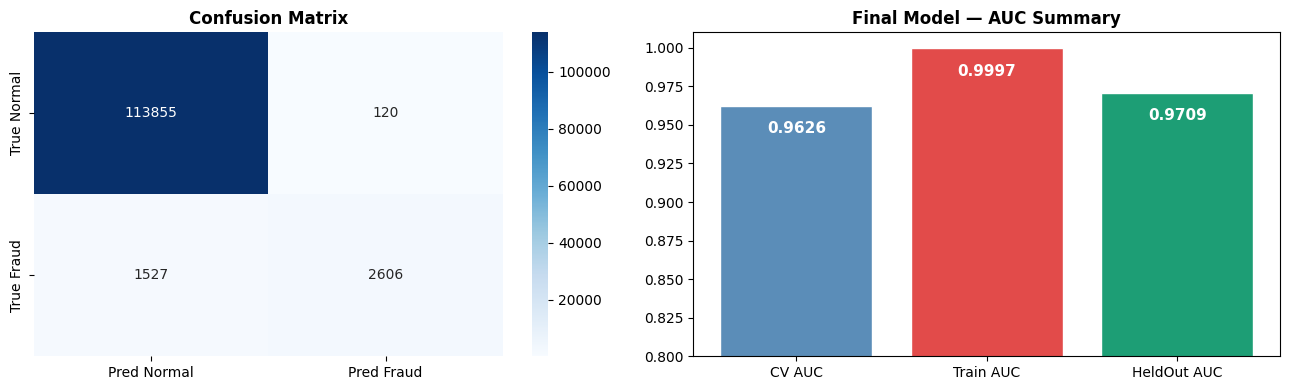


Pipeline val AUC on raw X_valid: 0.9647


2026/05/04 13:49:32 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/04 13:49:43 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



Pipeline saved successfully.
Run ID: b4b57e7a18064ee3bf1203dbce9fd233
🏃 View run XGBoost_Final at: https://dagshub.com/akave23/IEEE-CIS-Fraud-Detection-ML2.mlflow/#/experiments/2/runs/b4b57e7a18064ee3bf1203dbce9fd233
🧪 View experiment at: https://dagshub.com/akave23/IEEE-CIS-Fraud-Detection-ML2.mlflow/#/experiments/2


In [21]:
import mlflow
import xgboost as xgb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.metrics import roc_auc_score, confusion_matrix
from sklearn.impute import SimpleImputer


FINAL_PARAMS = {
    'n_estimators'     : 1500,
    'max_depth'        : 12,
    'learning_rate'    : 0.05,
    'subsample'        : 0.8,
    'colsample_bytree' : 0.7,
    'reg_alpha'        : 0.1,
    'reg_lambda'       : 1.0,
    'min_child_weight' : 10,
    'eval_metric'      : 'aucpr',
    'tree_method'      : 'hist',
    'device'           : 'cuda',
    'random_state'     : 42
}


with mlflow.start_run(run_name='XGBoost_Final') as run:

    print(f'Final training: X_tr_sel={X_tr_sel.shape} | y_train={y_train.shape}')


    cv_aucs, tr_aucs, oof_preds = run_cv_xgb(X_tr_sel, y_train, FINAL_PARAMS, n_splits=5)

    oof_auc = roc_auc_score(y_train, oof_preds)
    cv_m    = np.mean(cv_aucs)
    tr_m    = np.mean(tr_aucs)

  
    final_xgb = xgb.XGBClassifier(**FINAL_PARAMS)

    final_xgb.fit(
        X_tr_sel.values,
        y_train,
        eval_set=[(X_val_sel.values, y_valid)],
        verbose=False
    )

    val_preds = final_xgb.predict_proba(X_val_sel.values)[:, 1]
    val_auc   = roc_auc_score(y_valid, val_preds)

    print(f'\nOOF AUC     : {oof_auc:.4f}')
    print(f'CV AUC      : {cv_m:.4f} ± {np.std(cv_aucs):.4f}')
    print(f'Train AUC   : {tr_m:.4f}  | Gap: {tr_m-cv_m:.4f}')
    print(f'HeldOut AUC : {val_auc:.4f}')

    
    cm = confusion_matrix(y_valid, (val_preds >= 0.5).astype(int))

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
        xticklabels=['Pred Normal','Pred Fraud'],
        yticklabels=['True Normal','True Fraud']
    )

    axes[0].set_title('Confusion Matrix', fontweight='bold')

    metrics = {
        'CV AUC': cv_m,
        'Train AUC': tr_m,
        'HeldOut AUC': val_auc
    }

    bars = axes[1].bar(
        metrics.keys(),
        metrics.values(),
        color=['#5B8DB8','#E24B4A','#1D9E75'],
        edgecolor='white'
    )

    for bar, v in zip(bars, metrics.values()):
        axes[1].text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() - 0.01,
            f'{v:.4f}',
            ha='center',
            va='top',
            fontsize=11,
            fontweight='bold',
            color='white'
        )

    axes[1].set_ylim(0.80, 1.01)
    axes[1].set_title('Final Model — AUC Summary', fontweight='bold')

    plt.tight_layout()
    plt.savefig('xgb_final_results.png', dpi=130, bbox_inches='tight')
    plt.show()

    
    class XGBPreprocessor(BaseEstimator, TransformerMixin):
        def __init__(self):
            self.high_nan_cols_  = high_nan_cols
            self.missing_cols_   = missing_cols
            self.cap_bounds_     = cap_bounds
            self.high_corr_      = high_corr
            self.low_var_cols_   = low_var_cols
            self.imputer_final_  = imputer_final
            self.col_names_      = col_names
            self.final_features_ = FINAL_FEATURES

        def fit(self, X, y=None):
            return self

        def transform(self, X):

            df = X.copy() if isinstance(X, pd.DataFrame) else pd.DataFrame(X)

            df.drop(columns=[c for c in self.high_nan_cols_ if c in df.columns], inplace=True)

            for col in self.missing_cols_:
                df[col + '_was_nan'] = df[col].isnull().astype(np.int8) if col in df.columns else 0

            for col, (lo, hi) in self.cap_bounds_.items():
                if col in df.columns:
                    df[col] = df[col].clip(lo, hi)

            df.drop(columns=[c for c in self.high_corr_ + self.low_var_cols_
                             if c in df.columns], inplace=True)

            if 'TransactionDT' in df.columns:
                df['hour_of_day']  = (df['TransactionDT'] // 3600) % 24
                df['day_of_week']  = (df['TransactionDT'] // 86400) % 7
                df['day_of_month'] = (df['TransactionDT'] // 86400) % 30
                df['is_weekend']   = (df['day_of_week'] >= 5).astype(int)
                df['is_night']     = ((df['hour_of_day'] >= 22) | (df['hour_of_day'] <= 5)).astype(int)

            if 'TransactionAmt' in df.columns:
                df['amt_log']      = np.log1p(df['TransactionAmt'])
                df['amt_decimal']  = df['TransactionAmt'] % 1
                df['amt_is_round'] = (df['TransactionAmt'] % 1 < 0.01).astype(int)

            for c in self.col_names_:
                if c not in df.columns:
                    df[c] = 0

            df = pd.DataFrame(
                self.imputer_final_.transform(df[self.col_names_]),
                columns=self.col_names_
            )

            for c in self.final_features_:
                if c not in df.columns:
                    df[c] = 0

            return df[self.final_features_].values


    xgb_pipeline = Pipeline(steps=[
        ('preprocessor', XGBPreprocessor()),
        ('classifier', xgb.XGBClassifier(**FINAL_PARAMS))
    ])

    xgb_pipeline.fit(X_train, y_train)

    pipe_val_preds = xgb_pipeline.predict_proba(X_valid)[:, 1]
    pipe_val_auc   = roc_auc_score(y_valid, pipe_val_preds)

    print(f'\nPipeline val AUC on raw X_valid: {pipe_val_auc:.4f}')

   
    for k, v in FINAL_PARAMS.items():
        mlflow.log_param(k, str(v))

    mlflow.log_metric('auc_cv_mean', cv_m)
    mlflow.log_metric('auc_train_avg', tr_m)
    mlflow.log_metric('auc_oof', oof_auc)
    mlflow.log_metric('auc_val_holdout', val_auc)
    mlflow.log_metric('auc_pipeline_val', pipe_val_auc)
    mlflow.log_metric('overfitting_gap', tr_m - cv_m)

    mlflow.log_artifact('xgb_final_results.png')

    mlflow.sklearn.log_model(
        xgb_pipeline,
        artifact_path='xgb_pipeline'
    )

    print(f'\nPipeline saved successfully.')
    print(f'Run ID: {run.info.run_id}')